<a href="https://colab.research.google.com/github/nickjackson012/InjuryPredictionMachineLearning/blob/main/InjuryPredictionMachineLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
# load dataset from .csv file into a pandas DataFrame
df = pd.read_csv("collegiate_athlete_injury_dataset.csv")
# display table
df

,Athlete_ID,Age,Gender,Height_cm,Weight_kg,Position,Training_Intensity,Training_Hours_Per_Week,Recovery_Days_Per_Week,Match_Count_Per_Week,Rest_Between_Events_Days,Fatigue_Score,Performance_Score,Team_Contribution_Score,Load_Balance_Score,ACL_Risk_Score,Injury_Indicator
0,A001,24,Female,195,99,Center,2,13,2,3,1,1,99,58,100,4,0
1,A002,21,Male,192,65,Forward,8,14,1,3,1,4,55,63,83,73,0
2,A003,22,Male,163,83,Guard,8,8,2,1,3,6,58,62,100,62,0
3,A004,24,Female,192,90,Guard,1,13,1,1,1,7,82,74,78,51,0
4,A005,20,Female,173,79,Center,3,9,1,2,1,2,90,51,83,49,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,A196,23,Female,169,88,Guard,3,11,3,4,1,3,77,94,100,39,0
196,A197,21,Male,185,95,Forward,8,5,3,4,2,5,56,61,100,56,0
197,A198,19,Female,193,89,Center,5,6,2,1,1,5,81,81,100,25,0
198,A199,19,Male,166,55,Center,9,7,2,3,1,9,60,81,97,61,0


In [23]:
df.head(10)

,Athlete_ID,Age,Gender,Height_cm,Weight_kg,Position,Training_Intensity,Training_Hours_Per_Week,Recovery_Days_Per_Week,Match_Count_Per_Week,Rest_Between_Events_Days,Fatigue_Score,Performance_Score,Team_Contribution_Score,Load_Balance_Score,ACL_Risk_Score,Injury_Indicator
0,A001,24,Female,195,99,Center,2,13,2,3,1,1,99,58,100,4,0
1,A002,21,Male,192,65,Forward,8,14,1,3,1,4,55,63,83,73,0
2,A003,22,Male,163,83,Guard,8,8,2,1,3,6,58,62,100,62,0
3,A004,24,Female,192,90,Guard,1,13,1,1,1,7,82,74,78,51,0
4,A005,20,Female,173,79,Center,3,9,1,2,1,2,90,51,83,49,0
5,A006,22,Female,180,75,Guard,9,14,3,4,1,6,74,84,99,54,0
6,A007,22,Female,179,90,Forward,5,13,1,4,2,7,97,56,78,84,1
7,A008,24,Female,167,64,Center,6,7,2,3,3,2,62,70,100,42,0
8,A009,19,Female,166,91,Guard,4,19,2,3,3,2,58,67,80,50,0
9,A010,20,Female,162,63,Center,2,8,3,3,2,7,62,52,100,35,0


In [24]:
df.sample(10)

,Athlete_ID,Age,Gender,Height_cm,Weight_kg,Position,Training_Intensity,Training_Hours_Per_Week,Recovery_Days_Per_Week,Match_Count_Per_Week,Rest_Between_Events_Days,Fatigue_Score,Performance_Score,Team_Contribution_Score,Load_Balance_Score,ACL_Risk_Score,Injury_Indicator
119,A120,22,Male,193,87,Guard,8,19,1,4,3,9,67,90,62,100,1
18,A019,19,Female,167,77,Forward,6,6,3,4,3,9,87,68,100,60,0
77,A078,18,Female,175,63,Center,7,5,1,4,3,6,93,91,100,60,0
168,A169,18,Female,191,74,Center,9,19,2,4,1,4,99,67,78,66,0
128,A129,20,Male,188,75,Forward,8,5,3,1,1,9,56,75,100,72,1
6,A007,22,Female,179,90,Forward,5,13,1,4,2,7,97,56,78,84,1
102,A103,21,Female,194,80,Forward,2,6,3,2,3,2,71,71,100,30,0
118,A119,24,Male,160,79,Forward,8,15,2,1,1,6,79,51,98,59,0
131,A132,20,Male,185,90,Center,4,12,2,2,3,5,59,55,100,47,0
148,A149,22,Female,192,70,Guard,8,11,2,3,2,5,62,73,95,45,0


In [25]:
# Summary of the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Athlete_ID                200 non-null    object
 1   Age                       200 non-null    int64 
 2   Gender                    200 non-null    object
 3   Height_cm                 200 non-null    int64 
 4   Weight_kg                 200 non-null    int64 
 5   Position                  200 non-null    object
 6   Training_Intensity        200 non-null    int64 
 7   Training_Hours_Per_Week   200 non-null    int64 
 8   Recovery_Days_Per_Week    200 non-null    int64 
 9   Match_Count_Per_Week      200 non-null    int64 
 10  Rest_Between_Events_Days  200 non-null    int64 
 11  Fatigue_Score             200 non-null    int64 
 12  Performance_Score         200 non-null    int64 
 13  Team_Contribution_Score   200 non-null    int64 
 14  Load_Balance_Score        

In [26]:
# Summary of the data with basic statistics
df.describe()

,Age,Height_cm,Weight_kg,Training_Intensity,Training_Hours_Per_Week,Recovery_Days_Per_Week,Match_Count_Per_Week,Rest_Between_Events_Days,Fatigue_Score,Performance_Score,Team_Contribution_Score,Load_Balance_Score,ACL_Risk_Score,Injury_Indicator
count,200.000000,200.000000,200.000000,200.00000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,21.170000,180.805000,77.475000,5.10500,11.315000,1.985000,2.385000,1.975000,4.920000,74.465000,72.630000,93.395000,46.470000,0.070000
std,2.002787,11.529598,12.440789,2.49904,4.438952,0.811212,1.154748,0.817137,2.560543,14.636939,14.432762,8.660485,18.943956,0.255787
min,18.000000,160.000000,55.000000,1.00000,5.000000,1.000000,1.000000,1.000000,1.000000,50.000000,50.000000,62.000000,2.000000,0.000000
25%,19.000000,171.000000,67.000000,3.00000,7.000000,1.000000,1.000000,1.000000,3.000000,62.000000,60.750000,89.000000,33.000000,0.000000
50%,21.000000,182.500000,77.500000,5.00000,11.000000,2.000000,2.000000,2.000000,5.000000,74.000000,72.000000,98.000000,45.000000,0.000000
75%,23.000000,191.000000,89.000000,7.00000,15.000000,3.000000,3.000000,3.000000,7.000000,86.250000,85.000000,100.000000,60.000000,0.000000
max,24.000000,199.000000,99.000000,9.00000,19.000000,3.000000,4.000000,3.000000,9.000000,99.000000,99.000000,100.000000,100.000000,1.000000


In [27]:
# Cleaning up data because data has gaps in the real world
# If we feed a model blank data, the model will break

# Check for missing values in each column and sum them up
df.isnull().sum()

,0
Athlete_ID,0
Age,0
Gender,0
Height_cm,0
Weight_kg,0
Position,0
Training_Intensity,0
Training_Hours_Per_Week,0
Recovery_Days_Per_Week,0
Match_Count_Per_Week,0


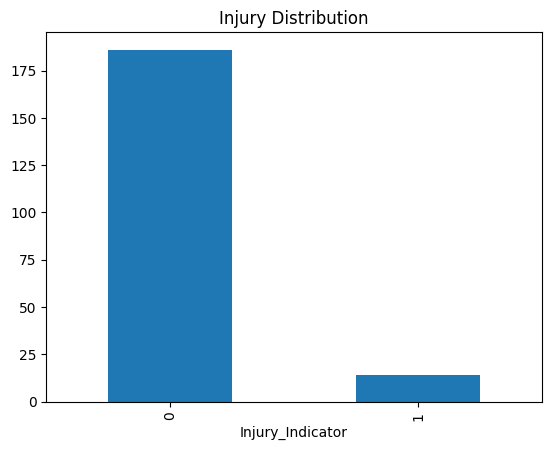

In [28]:
# Count the occurences of each unique value in the 'Injury_Indicator' column
# and plot it as a bar chart
df["Injury_Indicator"].value_counts().plot(kind="bar")

# Set the title of the plot
plt.title("Injury Distribution")

# Display the plot
plt.show()

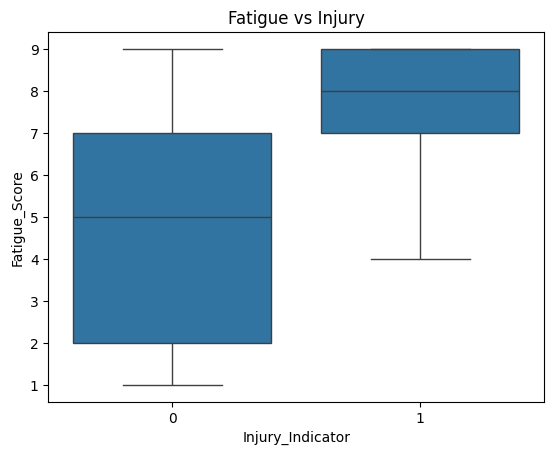

In [29]:
# Create a box plot to visualize the distribution of
# 'Fatigue_Score' for each 'Injury_Indicator'
sns.boxplot(x="Injury_Indicator", y="Fatigue_Score", data=df)
# Set the title of the plot
plt.title("Fatigue vs Injury")
# Display the plot
plt.show()

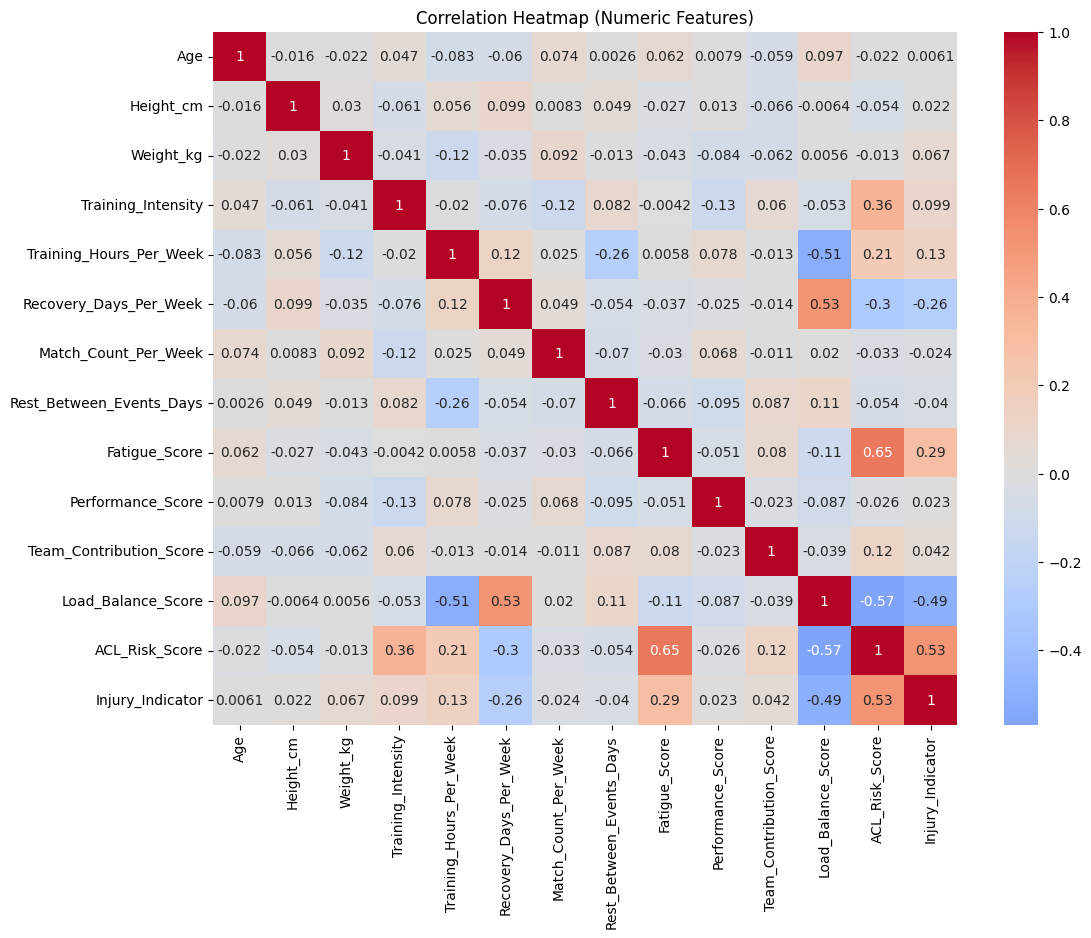

In [30]:
# Select only numeric columns for correlation analysis
num_cols =["Age", "Height_cm", "Weight_kg",
           "Training_Intensity", "Training_Hours_Per_Week",
           "Recovery_Days_Per_Week", "Match_Count_Per_Week",
           "Rest_Between_Events_Days", "Fatigue_Score",
           "Performance_Score", "Team_Contribution_Score",
           "Load_Balance_Score", "ACL_Risk_Score",
           "Injury_Indicator"]

# Filter num_cols to ensure only existing columns are included
num_cols = [c for c in num_cols if c in df.columns]
# Calculate the correlation matrix for the selected numeric columns
corr = df[num_cols].corr()

# Plot the correlation heatmap
plt.figure(figsize=(12,9))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap (Numeric Features)')
plt.show()

# As values are closer to 1, it indicates a higher positive correlation
# ACL_Risk_Score correlates the highest with Injury_Indicator

In [31]:
# drop useless columns
# Athlete_ID is not important because it is basically just a name
df.drop(['Athlete_ID'], axis=1, inplace=True)
df.head()

,Age,Gender,Height_cm,Weight_kg,Position,Training_Intensity,Training_Hours_Per_Week,Recovery_Days_Per_Week,Match_Count_Per_Week,Rest_Between_Events_Days,Fatigue_Score,Performance_Score,Team_Contribution_Score,Load_Balance_Score,ACL_Risk_Score,Injury_Indicator
0,24,Female,195,99,Center,2,13,2,3,1,1,99,58,100,4,0
1,21,Male,192,65,Forward,8,14,1,3,1,4,55,63,83,73,0
2,22,Male,163,83,Guard,8,8,2,1,3,6,58,62,100,62,0
3,24,Female,192,90,Guard,1,13,1,1,1,7,82,74,78,51,0
4,20,Female,173,79,Center,3,9,1,2,1,2,90,51,83,49,0


In [32]:
# Convert categorical data to numerical data
# Takes categorical data and converts it to 0 or 1 (True or False)
df_encoded = pd.get_dummies(df, columns=["Gender", "Position"], drop_first=True)
df_encoded.head()

,Age,Height_cm,Weight_kg,Training_Intensity,Training_Hours_Per_Week,Recovery_Days_Per_Week,Match_Count_Per_Week,Rest_Between_Events_Days,Fatigue_Score,Performance_Score,Team_Contribution_Score,Load_Balance_Score,ACL_Risk_Score,Injury_Indicator,Gender_Male,Position_Forward,Position_Guard
0,24,195,99,2,13,2,3,1,1,99,58,100,4,0,False,False,False
1,21,192,65,8,14,1,3,1,4,55,63,83,73,0,True,True,False
2,22,163,83,8,8,2,1,3,6,58,62,100,62,0,True,False,True
3,24,192,90,1,13,1,1,1,7,82,74,78,51,0,False,False,True
4,20,173,79,3,9,1,2,1,2,90,51,83,49,0,False,False,False


In [33]:
# We are avoiding giving the model the answers that we want it to predict
# X is everything the model sees
# y is what we want to predict

X = df_encoded.drop("Injury_Indicator", axis=1)
y = df_encoded['Injury_Indicator']

X.head()

,Age,Height_cm,Weight_kg,Training_Intensity,Training_Hours_Per_Week,Recovery_Days_Per_Week,Match_Count_Per_Week,Rest_Between_Events_Days,Fatigue_Score,Performance_Score,Team_Contribution_Score,Load_Balance_Score,ACL_Risk_Score,Gender_Male,Position_Forward,Position_Guard
0,24,195,99,2,13,2,3,1,1,99,58,100,4,False,False,False
1,21,192,65,8,14,1,3,1,4,55,63,83,73,True,True,False
2,22,163,83,8,8,2,1,3,6,58,62,100,62,True,False,True
3,24,192,90,1,13,1,1,1,7,82,74,78,51,False,False,True
4,20,173,79,3,9,1,2,1,2,90,51,83,49,False,False,False


In [34]:
from sklearn.preprocessing import StandardScaler
# Transforms every column so mean = 0 and spread = 1.
# Concrete example: an ACL_Risk_Score of 72 becomes ~0.8;
# a score of 45 becomes ~ -1.3.
# The order is preserved — highest is still highest —
# but now every column competes on the same scale.
scaler = StandardScaler()

numerical_cols = ['Age', 'Height_cm',
'Weight_kg',
'Training_Intensity',
'Training_Hours_Per_Week',
'Recovery_Days_Per_Week',
'Match_Count_Per_Week',
'Rest_Between_Events_Days',
'Fatigue_Score',
'Performance_Score',
'Team_Contribution_Score',
'Load_Balance_Score',
'ACL_Risk_Score']

X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

X.head()

,Age,Height_cm,Weight_kg,Training_Intensity,Training_Hours_Per_Week,Recovery_Days_Per_Week,Match_Count_Per_Week,Rest_Between_Events_Days,Fatigue_Score,Performance_Score,Team_Contribution_Score,Load_Balance_Score,ACL_Risk_Score,Gender_Male,Position_Forward,Position_Guard
0,1.416577,1.234269,1.734537,-1.245595,0.380547,0.018537,0.533920,-1.196184,-1.534767,1.680445,-1.016210,0.764573,-2.247502,False,False,False
1,-0.085095,0.973416,-1.005266,1.161352,0.606390,-1.217279,0.533920,-1.196184,-0.360200,-1.333192,-0.668906,-1.203291,1.403961,True,True,False
2,0.415462,-1.548162,0.445218,1.161352,-0.748672,0.018537,-1.202406,1.257527,0.422844,-1.127717,-0.738367,0.764573,0.821844,True,False,True
3,1.416577,0.973416,1.009295,-1.646753,0.380547,-1.217279,-1.202406,-1.196184,0.814366,0.516085,0.095161,-1.782075,0.239726,False,False,True
4,-0.585652,-0.678652,0.122888,-0.844437,-0.522828,-1.217279,-0.334243,-1.196184,-1.143245,1.064019,-1.502434,-1.203291,0.133887,False,False,False


In [35]:
X.describe()

,Age,Height_cm,Weight_kg,Training_Intensity,Training_Hours_Per_Week,Recovery_Days_Per_Week,Match_Count_Per_Week,Rest_Between_Events_Days,Fatigue_Score,Performance_Score,Team_Contribution_Score,Load_Balance_Score,ACL_Risk_Score
count,2.000000e+02,2.000000e+02,2.000000e+02,2.000000e+02,2.000000e+02,2.000000e+02,2.000000e+02,2.000000e+02,2.000000e+02,2.000000e+02,2.000000e+02,2.000000e+02,2.000000e+02
mean,-8.815171e-16,-5.995204e-16,4.551914e-16,-1.687539e-16,1.110223e-16,-9.769963e-17,1.421085e-16,-8.437695e-17,-2.220446e-18,-2.298162e-16,3.375078e-16,4.440892e-16,6.217249e-17
std,1.002509e+00,1.002509e+00,1.002509e+00,1.002509e+00,1.002509e+00,1.002509e+00,1.002509e+00,1.002509e+00,1.002509e+00,1.002509e+00,1.002509e+00,1.002509e+00,1.002509e+00
min,-1.586766e+00,-1.809014e+00,-1.811091e+00,-1.646753e+00,-1.426203e+00,-1.217279e+00,-1.202406e+00,-1.196184e+00,-1.534767e+00,-1.675650e+00,-1.571895e+00,-3.634183e+00,-2.353341e+00
25%,-1.086209e+00,-8.525540e-01,-8.441013e-01,-8.444372e-01,-9.745156e-01,-1.217279e+00,-1.202406e+00,-1.196184e+00,-7.517225e-01,-8.537496e-01,-8.251928e-01,-5.087508e-01,-7.128290e-01
50%,-8.509472e-02,1.473818e-01,2.014561e-03,-4.212157e-02,-7.114077e-02,1.853725e-02,-3.342428e-01,3.067138e-02,3.132177e-02,-3.184866e-02,-4.376023e-02,5.330598e-01,-7.779203e-02
75%,9.160196e-01,8.864648e-01,9.287129e-01,7.601940e-01,8.322341e-01,1.254354e+00,5.339204e-01,1.257527e+00,8.143661e-01,8.071752e-01,8.592286e-01,7.645732e-01,7.160042e-01
max,1.416577e+00,1.582072e+00,1.734537e+00,1.562510e+00,1.735609e+00,1.254354e+00,1.402084e+00,1.257527e+00,1.597410e+00,1.680445e+00,1.831678e+00,7.645732e-01,2.832794e+00


In [36]:
correlations = df_encoded.corr()["Injury_Indicator"].sort_values(ascending=False)
correlations

,Injury_Indicator
Injury_Indicator,1.000000
ACL_Risk_Score,0.525180
Fatigue_Score,0.292475
Training_Hours_Per_Week,0.130958
Training_Intensity,0.098502
Weight_kg,0.066876
Position_Guard,0.063855
Team_Contribution_Score,0.042442
Performance_Score,0.023475
Height_cm,0.021691


In [37]:
X_final = X.copy()
y_final = y.copy()

print("Final Feature Shape: ", X_final.shape)
print("Target Shape: ", y_final.shape)

Final Feature Shape:  (200, 16)
Target Shape:  (200,)


In [38]:
# Import libraries for splitting data, creating models, and evaluating results.
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [39]:
# Split the data into training and testing sets.
# 20% of the model goes to testing
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final,
    test_size=0.2,
    random_state=42,
    stratify=y_final   # keeps injured/non-injured ratio equal
)

X_train.head()

,Age,Height_cm,Weight_kg,Training_Intensity,Training_Hours_Per_Week,Recovery_Days_Per_Week,Match_Count_Per_Week,Rest_Between_Events_Days,Fatigue_Score,Performance_Score,Team_Contribution_Score,Load_Balance_Score,ACL_Risk_Score,Gender_Male,Position_Forward,Position_Guard
43,0.916020,-0.069996,0.606383,-1.245595,-0.522828,-1.217279,-0.334243,0.030671,-0.751723,0.516085,-1.294052,-0.045724,-0.554070,False,True,False
179,-0.085095,-1.809014,-1.085849,0.359036,0.380547,0.018537,-1.202406,-1.196184,0.422844,0.516085,-0.529985,0.533060,-0.183632,False,False,True
128,-0.585652,0.625612,-0.199442,1.161352,-1.426203,1.254354,-1.202406,-1.196184,1.597410,-1.264700,0.164622,0.764573,1.351041,True,True,False
13,0.415462,0.016955,1.009295,1.562510,-0.296984,-1.217279,-0.334243,-1.196184,0.422844,-1.470175,1.762217,-0.740264,1.351041,False,True,False
173,-0.085095,1.147318,0.928713,-0.042122,1.058078,1.254354,-1.202406,1.257527,0.031322,-1.059225,0.650847,0.764573,-0.342391,False,True,False


In [40]:
# Create a logistic regression model with balanced class weights
log_model = LogisticRegression(class_weight='balanced', C=0.001)
# Train the model using the training data
log_model.fit(X_train, y_train)

LogisticRegression(C=0.001, class_weight='balanced')

In [41]:
X_test.head()

,Age,Height_cm,Weight_kg,Training_Intensity,Training_Hours_Per_Week,Recovery_Days_Per_Week,Match_Count_Per_Week,Rest_Between_Events_Days,Fatigue_Score,Performance_Score,Team_Contribution_Score,Load_Balance_Score,ACL_Risk_Score,Gender_Male,Position_Forward,Position_Guard
50,0.415462,0.799514,-0.199442,-0.844437,-0.748672,-1.217279,0.533920,1.257527,1.205888,0.036643,-1.085670,-0.161481,-0.024872,False,False,False
138,-1.586766,-1.461211,-0.682936,0.760194,0.832234,-1.217279,0.533920,1.257527,-1.143245,1.132511,1.275993,-1.666318,0.768924,True,False,False
65,0.415462,1.495121,-1.005266,0.760194,0.154703,1.254354,-0.334243,0.030671,1.205888,-1.607159,-0.043760,0.764573,0.716004,True,False,False
186,0.415462,0.799514,0.686965,-0.042122,-0.296984,0.018537,1.402084,-1.196184,-1.534767,0.584577,-0.738367,-0.277237,-0.130712,True,True,False
107,-1.086209,-0.243897,-0.844101,-0.844437,1.058078,1.254354,0.533920,1.257527,1.597410,1.543461,0.650847,0.764573,0.610165,False,False,True


In [42]:
# Make predictions on the test data
log_preds = log_model.predict(X_test)
log_preds

array([0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1])

In [43]:
# Create a tree model with balanced class weights
tree_model = DecisionTreeClassifier(class_weight='balanced', random_state=42)
# Train the model using the training data
tree_model.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=42)

In [44]:
# Make predictions on the test data
tree_preds = tree_model.predict(X_test)
tree_preds

array([0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [45]:
print("Logistic Accuracy:", accuracy_score(y_test, log_preds))
print("Tree Accuracy:", accuracy_score(y_test, tree_preds))

Logistic Accuracy: 0.875
Tree Accuracy: 0.875


In [46]:
# Print the accuracy of both models

print("Logistic Precision:", precision_score(y_test, log_preds))
print("Logistic Recall:", recall_score(y_test, log_preds))

print("Tree Precision:", precision_score(y_test, tree_preds))
print("Tree Recall:", recall_score(y_test, tree_preds))

Logistic Precision: 0.3333333333333333
Logistic Recall: 0.6666666666666666
Tree Precision: 0.0
Tree Recall: 0.0


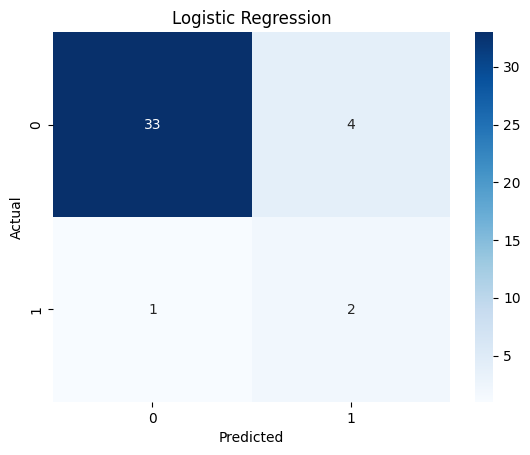

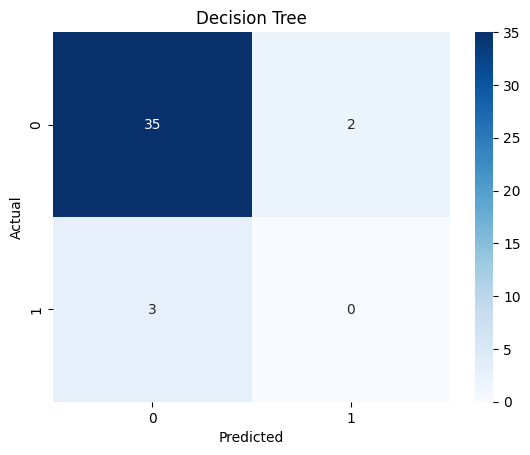

In [47]:
# Plot confusion matrix heatmaps for logistic regression and decision tree predictions
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_confusion_matrix(y_test, log_preds, "Logistic Regression")
plot_confusion_matrix(y_test, tree_preds, "Decision Tree")

In [48]:
# Get and sort feature importance scores from the logistic regression model
importance_log = pd.Series(log_model.coef_[0], index=X_train.columns)
importance_log.sort_values(ascending=False)

,0
ACL_Risk_Score,0.073732
Fatigue_Score,0.038111
Training_Intensity,0.017630
Training_Hours_Per_Week,0.017123
Weight_kg,0.012127
Height_cm,0.009868
Position_Guard,0.003988
Team_Contribution_Score,0.003710
Age,-0.000966
Position_Forward,-0.002124


In [49]:
# Show the importance of each feature for the Decision Tree model.
importance_tree = pd.Series(tree_model.feature_importances_, index=X_train.columns)
importance_tree.sort_values(ascending=False)

,0
ACL_Risk_Score,9.223297e-01
Height_cm,3.794567e-02
Team_Contribution_Score,3.650470e-02
Load_Balance_Score,3.219908e-03
Position_Guard,3.633457e-16
Age,3.353023e-17
Weight_kg,0.000000e+00
Training_Intensity,0.000000e+00
Rest_Between_Events_Days,0.000000e+00
Match_Count_Per_Week,0.000000e+00


In [50]:
print("Training Accuracy: ", log_model.score(X_train, y_train))
print("Test Accuracy: ", log_model.score(X_test, y_test))

Training Accuracy:  0.90625
Test Accuracy:  0.875



--- Support Vector Machine (SVM) ---
SVM Accuracy: 0.95
SVM Precision: 0.6666666666666666
SVM Recall: 0.6666666666666666


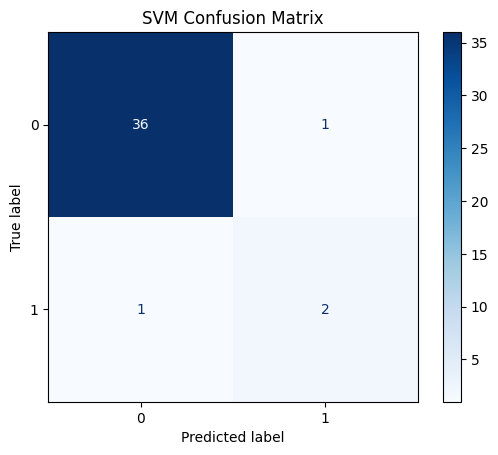


--- k-Nearest Neighbors (k-NN) ---
k-NN Accuracy: 0.9
k-NN Precision: 0.0
k-NN Recall: 0.0


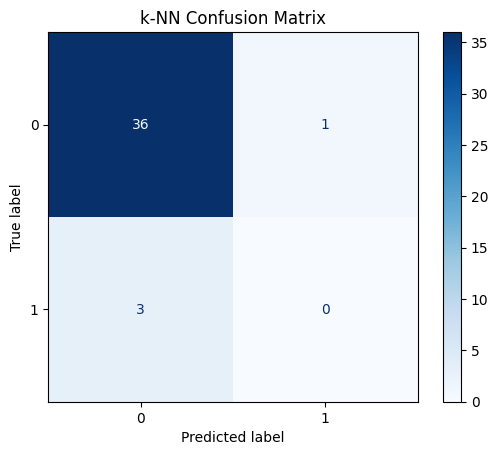

In [59]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(cmap="Blues")
    plt.title(title)
    plt.show()

print("\n--- Support Vector Machine (SVM) ---")
# Create an SVM classifier with balanced class weights
svm_model = SVC(class_weight='balanced', random_state=42)
# Train the model
svm_model.fit(X_train, y_train)
# Make predictions
svm_preds = svm_model.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, svm_preds))
print("SVM Precision:", precision_score(y_test, svm_preds, zero_division=0))
print("SVM Recall:", recall_score(y_test, svm_preds, zero_division=0))
plot_confusion_matrix(y_test, svm_preds, "SVM Confusion Matrix")

print("\n--- k-Nearest Neighbors (k-NN) ---")
# Create a k-NN classifier
knn_model = KNeighborsClassifier()
# Train the model
knn_model.fit(X_train, y_train)
# Make predictions
knn_preds = knn_model.predict(X_test)

print("k-NN Accuracy:", accuracy_score(y_test, knn_preds))
print("k-NN Precision:", precision_score(y_test, knn_preds, zero_division=0))
print("k-NN Recall:", recall_score(y_test, knn_preds, zero_division=0))
plot_confusion_matrix(y_test, knn_preds, "k-NN Confusion Matrix")

In [51]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Base model
base_model = LogisticRegression(class_weight='balanced', max_iter=1000)

# Parameter grid to test
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100]  # Regularization strength
}

# Create GridSearchCV
grid = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    cv=10,
    scoring="recall"  # Focus on catching injuries
)

# Fit on scaled training data (already scaled from Week 3)
grid.fit(X_train, y_train)

# Get the best model
best_model = grid.best_estimator_

print("Best C value:", grid.best_params_)

Best C value: {'C': 0.01}


Accuracy: 0.925
Precision: 0.5
Recall: 1.0
F1 Score: 0.6666666666666666


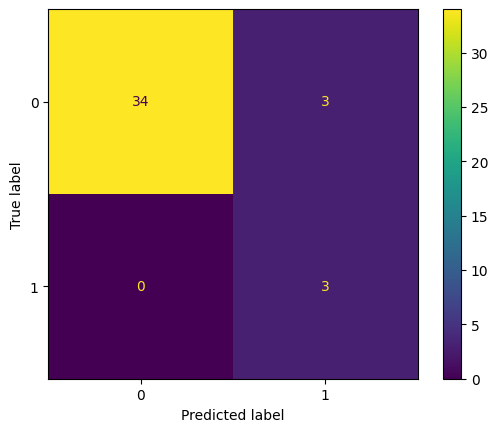

In [52]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Predict on test set
y_pred = best_model.predict(X_test)

# Evaluate metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))
print("F1 Score:", f1_score(y_test, y_pred, zero_division=0))

# Visualize confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [53]:
print("Training Accuracy:", best_model.score(X_train, y_train))
print("Test Accuracy:", best_model.score(X_test, y_test))

Training Accuracy: 0.9
Test Accuracy: 0.925


In [54]:
# Get predicted probabilities of injury
probs = best_model.predict_proba(X_test)[:, 1]

# Define simple risk levels: Low (<0.33), Medium (0.33-0.66), High (>=0.66)
y_risk = [
    "Low Risk" if p < 0.33
    else ("Medium Risk" if p < 0.66 else "High Risk")
    for p in probs
]

# See first 10 predictions
list(zip(probs[:10], y_risk[:10]))

[(np.float64(0.37419111719261916), 'Medium Risk'),
 (np.float64(0.4556156619084492), 'Medium Risk'),
 (np.float64(0.34224926215926776), 'Medium Risk'),
 (np.float64(0.2593841507582856), 'Low Risk'),
 (np.float64(0.28950477116978923), 'Low Risk'),
 (np.float64(0.10807699267803025), 'Low Risk'),
 (np.float64(0.6819425670204203), 'High Risk'),
 (np.float64(0.1314258008957587), 'Low Risk'),
 (np.float64(0.2605638109220165), 'Low Risk'),
 (np.float64(0.2066091598340183), 'Low Risk')]

In [55]:
def predict_injury_risk(model, athlete_data, training_columns, scaler, numeric_cols):
    """
    athlete_data: dict of features for one athlete
    training_columns: X_train.columns to match model
    scaler: the fitted scaler used on training data
    numeric_cols: list of numeric feature names that need scaling
    """
    import pandas as pd
    # Convert dict to DataFrame
    athlete_df = pd.DataFrame([athlete_data])

    # Encode categorical features
    athlete_df_encoded = pd.get_dummies(athlete_df)

    # Add missing columns
    for col in training_columns:
        if col not in athlete_df_encoded.columns:
            athlete_df_encoded[col] = 0

    # Reorder columns to match training
    athlete_df_encoded = athlete_df_encoded[training_columns]

    # Scale numeric columns
    athlete_df_encoded[numeric_cols] = scaler.transform(athlete_df_encoded[numeric_cols])

    # Predict probability
    prob = model.predict_proba(athlete_df_encoded)[:,1][0]
    risk = "Low Risk" if prob < 0.33 else ("Medium Risk" if prob < 0.66 else "High Risk")

    return prob, risk

In [58]:
# Example: Low-risk athlete
athlete1 = {
    "Age": 20,
    "Height_cm": 180,
    "Weight_kg": 75,
    "Training_Intensity": 5,
    "Training_Hours_Per_Week": 8,
    "Recovery_Days_Per_Week": 3,
    "Match_Count_Per_Week": 1,
    "Rest_Between_Events_Days": 2,
    "Fatigue_Score": 2,
    "Performance_Score": 85,
    "Team_Contribution_Score": 80,
    "Load_Balance_Score": 80,
    "ACL_Risk_Score": 50
}


# Example: High-risk athlete
athlete2 = {
    "Age": 24,
    "Height_cm": 185,
    "Weight_kg": 85,
    "Training_Intensity": 9,
    "Training_Hours_Per_Week": 18,
    "Recovery_Days_Per_Week": 1,
    "Match_Count_Per_Week": 4,
    "Rest_Between_Events_Days": 1,
    "Fatigue_Score": 9,
    "Performance_Score": 70,
    "Team_Contribution_Score": 60,
    "Load_Balance_Score": 40,
    "ACL_Risk_Score": 80
}

prob, risk = predict_injury_risk(best_model, athlete1, X_train.columns, scaler, numerical_cols)
print("Athlete 1 Injury Probability:", prob)
print("Athlete 1 Injury Risk Level:", risk)

prob, risk = predict_injury_risk(best_model, athlete2, X_train.columns, scaler, numerical_cols)
print("Athlete 2 Injury Probability:", prob)
print("Athlete 2 Injury Risk Level:", risk)

Athlete 1 Injury Probability: 0.324700770313754
Athlete 1 Injury Risk Level: Low Risk
Athlete 2 Injury Probability: 0.9285778148498014
Athlete 2 Injury Risk Level: High Risk


In [57]:
# Allows us to share the created model without having to rewrite code
# creates a downloadable .pkl file in the notebook
# Use pandas or pickle import to load .pkl file
import joblib
joblib.dump(best_model, "injury_model.pkl")

['injury_model.pkl']